In [71]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings



warnings.filterwarnings('ignore')

In [72]:
# --- 1. DATA LOADING AND UNIFICATION ---

def load_and_unify_data(spp_filepath, kinematic_filepath):
    """
    Loads SPP and Kinematic data, aligns them, calculates differences,
    and returns a single unified DataFrame using explicit column names.
    """
    try:
        spp_df = pd.read_csv(spp_filepath)
        kin_df = pd.read_csv(kinematic_filepath)
        print(f"✓ SPP file loaded with {len(spp_df)} rows.")
        print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
    except Exception as e:
        print(f"✗ Error loading files: {e}")
        return None, None, None, None, None

    spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
    kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

    c = pd.merge(spp_df, kin_df, how='inner', on='GPST')

    unified_df = c.copy()

    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

    feature_cols = ['avg_snr', 'min_snr', 'max_residual', 'x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)']

    return unified_df, feature_cols, 'x_x', 'y_x', 'z_x'

In [73]:

# --- 5. MAIN EXECUTION ---

spp_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\6_EW_EVENING_S.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\6_EW_Evening_K.csv'
    # 1) step is to return merged data
unified_df1, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df1)

✓ SPP file loaded with 15734 rows.
✓ Kinematic file loaded with 12252 rows.


12252

In [74]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\6_EW_MORNING_S.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\6_EW_Morning_K.csv'
    # 1) step is to return merged data
unified_df2, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df2)

✓ SPP file loaded with 15291 rows.
✓ Kinematic file loaded with 15060 rows.


15060

In [75]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\6_NS_EVENING_S.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\6_NS_Evening_K.csv'
    # 1) step is to return merged data
unified_df3, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df3) 

✓ SPP file loaded with 14870 rows.
✓ Kinematic file loaded with 11375 rows.


11374

In [76]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\6_NS_MORNING_S.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\6_NS_Morning_K.csv'
    # 1) step is to return merged data
unified_df4, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df4) 

✓ SPP file loaded with 15070 rows.
✓ Kinematic file loaded with 13307 rows.


13307

In [77]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\7_EW_EVENING_S.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\7_EW_Evening_K.csv'
    # 1) step is to return merged data
unified_df5, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df5)

✓ SPP file loaded with 15645 rows.
✓ Kinematic file loaded with 15286 rows.


15286

In [78]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\7_EW_MORNING_S.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\7_EW_Morning_K.csv'
    # 1) step is to return merged data
unified_df6, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df6)

✓ SPP file loaded with 15543 rows.
✓ Kinematic file loaded with 15075 rows.


15075

In [79]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\7_NS_EVENING_S.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\7_NS_Evening_K.csv'
    # 1) step is to return merged data
unified_df7, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df7) 

✓ SPP file loaded with 15655 rows.
✓ Kinematic file loaded with 13947 rows.


13946

In [80]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\7_NS_MORNING_S.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\7_NS_Morning_K.csv'
    # 1) step is to return merged data
unified_df8, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df8) 

✓ SPP file loaded with 15642 rows.
✓ Kinematic file loaded with 14279 rows.


14279

In [81]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\10_EW_MORNING_S.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\10_EW_Morning_K.csv'
    # 1) step is to return merged data
unified_df9, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df9)

✓ SPP file loaded with 15675 rows.
✓ Kinematic file loaded with 15512 rows.


15512

In [82]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\10_NS_MORNING_S.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\research_data\notebooks\10_NS_Morning_K.csv'
    # 1) step is to return merged data
unified_df10, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df10) 

✓ SPP file loaded with 15027 rows.
✓ Kinematic file loaded with 13541 rows.


13541

In [83]:
# Append all dataframes
unified_df = pd.concat([unified_df1, unified_df2, unified_df3,unified_df4, unified_df5, unified_df6, unified_df7, unified_df8, unified_df9], ignore_index=True)

# Sort by GPST
unified_df = unified_df.sort_values('GPST').reset_index(drop=True)
unified_df = unified_df.drop(columns=["Unnamed: 0"])
print(f"Total number of rows after appending: {len(unified_df)}")
print("\nFirst few rows to verify sorting:")
print(unified_df.head(1).T)

Total number of rows after appending: 126091

First few rows to verify sorting:
                                0
GPST          2023-12-06 01:59:08
avg_snr                     31.75
min_snr                      26.0
max_residual               1.6368
x_x                   459252.2586
y_x                  5634017.5265
z_x                  2947006.7061
ns                            8.0
sdx(m)                    52.2081
sdy(m)                    36.9664
sdz(m)                    49.3526
sdxy(m)                   40.7052
sdyz(m)                  -37.1917
sdzx(m)                  -50.0592
x_y                   459291.9968
y_y                   5634082.203
z_y                  2946965.7544
diff_x                    39.7382
diff_y                    64.6765
diff_z                   -40.9517


In [84]:
unified_df.head()

,GPST,avg_snr,min_snr,max_residual,x_x,y_x,z_x,ns,sdx(m),sdy(m),sdz(m),sdxy(m),sdyz(m),sdzx(m),x_y,y_y,z_y,diff_x,diff_y,diff_z
0,2023-12-06 01:59:08,31.750000,26.0,1.6368,459252.2586,5.634018e+06,2.947007e+06,8.0,52.2081,36.9664,49.3526,40.7052,-37.1917,-50.0592,459291.9968,5.634082e+06,2.946966e+06,39.7382,64.6765,-40.9517
1,2023-12-06 01:59:09,31.625000,25.0,1.7018,459252.7407,5.634016e+06,2.947006e+06,8.0,52.2223,36.9710,49.3521,40.7137,-37.1948,-50.0660,459289.5836,5.634087e+06,2.946966e+06,36.8429,71.1549,-39.4826
2,2023-12-06 01:59:49,29.000000,23.0,5.5528,459308.8238,5.634051e+06,2.946946e+06,11.0,10.2943,17.0425,16.1441,3.2766,10.4717,-11.0646,459295.8737,5.634077e+06,2.946962e+06,-12.9501,26.0052,16.4584
3,2023-12-06 02:06:09,27.500000,19.0,11.0868,459293.8285,5.634046e+06,2.946964e+06,16.0,4.6884,16.7968,9.3480,-2.4012,11.4236,-3.5037,459293.3256,5.634080e+06,2.946963e+06,-0.5029,34.6117,-0.4802
4,2023-12-06 02:06:25,27.666667,16.0,11.5613,459294.7681,5.634057e+06,2.946969e+06,15.0,4.6947,17.2442,9.9720,-2.3391,12.0011,-3.4614,459285.2562,5.634097e+06,2.946964e+06,-9.5119,39.3426,-5.2728


In [85]:
# --- 2. MODEL TRAINING AND EVALUATION ---

def train_ensemble_and_evaluate(unified_df, feature_cols):
    # --- Data prep ---
    X = unified_df[feature_cols]
    y = unified_df[['diff_x', 'diff_y', 'diff_z']]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_train_scaled = y_scaler.fit_transform(y_train)
    y_test_scaled = y_scaler.transform(y_test)

    # --- Train Random Forest Regressor ---
    print(f"\n{'='*80}\nTraining Random Forest Regressor\n{'='*80}")
    
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train_scaled, y_train_scaled)

    # --- Make predictions ---
    y_pred_scaled = rf_model.predict(X_test_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    y_test_vals = y_test.values

    # --- Evaluation ---
    print("\n" + "="*80 + "\nFINAL EVALUATION: RANDOM FOREST MODEL\n" + "="*80)
    per_axis_rmse = []
    for i, axis in enumerate(['X', 'Y', 'Z']):
        rmse = np.sqrt(mean_squared_error(y_test_vals[:, i], y_pred[:, i]))
        per_axis_rmse.append(rmse)
        print(f"--- Axis {axis} ---\n  R² Score: {r2_score(y_test_vals[:, i], y_pred[:, i]):.4f}\n  RMSE (m): {rmse:.4f}\n")

    overall_rmse = np.mean(per_axis_rmse)
    print(f"Overall mean RMSE (m): {overall_rmse:.4f}")

    # --- Plot feature importance ---
    plt.figure(figsize=(10, 6))
    feature_importance = rf_model.feature_importances_
    indices = np.argsort(feature_importance)[::-1]
    
    plt.title("Random Forest Feature Importance",fontsize=18)
    plt.bar(range(len(feature_importance)), feature_importance[indices],color='skyblue')
    plt.xticks(range(len(feature_importance)), [feature_cols[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

    return rf_model, x_scaler, y_scaler, X_test, y_pred




In [86]:
# --- 3. ACCURACY IMPROVEMENT ANALYSIS ---

def calculate_accuracy_improvement(test_df, y_pred_corrected, spp_cols):
    """Calculates and prints the before-and-after 3D error comparison."""
    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # Original 3D Error from diff_x, diff_y, diff_z
    original_3d_errors = np.sqrt(test_df['diff_x']**2 + test_df['diff_y']**2 + test_df['diff_z']**2)
    mean_original_error = original_3d_errors.mean()

    # Corrected 3D Error = x_x + correction using AI
    corrected_spp_x = test_df[spp_x_col] + y_pred_corrected[:, 0]
    corrected_spp_y = test_df[spp_y_col] + y_pred_corrected[:, 1]
    corrected_spp_z = test_df[spp_z_col] + y_pred_corrected[:, 2]

    # overall error for improvement_distnace = testing_kinematic -  Corrected 3D Error
    corrected_diff_x = test_df['x_y'] - corrected_spp_x
    corrected_diff_y = test_df['y_y'] - corrected_spp_y
    corrected_diff_z = test_df['z_y'] - corrected_spp_z

    corrected_3d_errors = np.sqrt(corrected_diff_x**2 + corrected_diff_y**2 + corrected_diff_z**2)
    mean_corrected_error = corrected_3d_errors.mean()

    improvement = mean_original_error - mean_corrected_error
    improvement_percent = (improvement / mean_original_error) * 100 if mean_original_error != 0 else 0

    print("\n" + "="*80 + "\nMODEL ACCURACY IMPROVEMENT ANALYSIS\n" + "="*80)
    print(f"Mean 3D Error (Original): {mean_original_error:.4f} m")
    print(f"Mean 3D Error (Corrected): {mean_corrected_error:.4f} m")
    print(f"\nImprovement: {improvement:.4f} m ({improvement_percent:.2f}%)")

In [87]:
unified_df[['diff_x','diff_y','diff_z']].describe()

,diff_x,diff_y,diff_z
count,126091.000000,126091.000000,126091.000000
mean,-1.340336,-8.992035,-8.929508
std,3.527318,9.387613,4.972769
min,-49.807700,-87.094300,-49.909400
25%,-2.902450,-13.975450,-11.973150
50%,-1.079200,-8.550300,-8.280000
75%,0.611700,-3.484600,-5.670300
max,43.175500,71.154900,46.950300


In [88]:
from sklearn.ensemble import IsolationForest

# Ensure diff columns exist
cols = ['diff_x', 'diff_y', 'diff_z']
missing = [c for c in cols if c not in unified_df.columns]
if missing:
    raise KeyError(f'Missing required diff columns in unified_df: {missing}')

# Handle NaNs directly in unified_df (fill with median)
unified_df[cols] = unified_df[cols].fillna(unified_df[cols].median())

# Train IsolationForest on the diff columns
iso = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(unified_df[cols])

# Predict anomalies (-1 = anomaly, 1 = normal)
unified_df['anomaly'] = iso.predict(unified_df[cols])

# Print summary
print('Anomaly value counts (1 = normal, -1 = anomaly):')
print(unified_df['anomaly'].value_counts())


Anomaly value counts (1 = normal, -1 = anomaly):
anomaly
 1    107648
-1     18443
Name: count, dtype: int64


In [91]:
unified_df.head()
unified_df.to_csv("data_after_outlier_detection1.csv", index=True)

In [23]:
unified_df = unified_df[unified_df['anomaly'] == 1].drop(columns=['anomaly'])
print(f"Data size before cleaning: {len(unified_df)}")

Data size before cleaning: 61388


In [43]:
unified_df[['diff_x', 'diff_y', 'diff_z']].describe()

,diff_x,diff_y,diff_z
count,73185.000000,73185.000000,73185.000000
mean,-0.786642,-7.376992,-7.948307
std,2.519283,7.983715,4.401044
min,-21.541200,-82.444700,-49.909400
25%,-2.375700,-12.037300,-10.409900
50%,-0.771100,-7.208300,-7.534300
75%,0.677700,-2.620900,-5.129400
max,39.795100,47.439100,46.950300



Training Random Forest Regressor

FINAL EVALUATION: RANDOM FOREST MODEL
--- Axis X ---
  R² Score: 0.7065
  RMSE (m): 1.3399

--- Axis Y ---
  R² Score: 0.7782
  RMSE (m): 3.7205

--- Axis Z ---
  R² Score: 0.8024
  RMSE (m): 1.9327

Overall mean RMSE (m): 2.3310


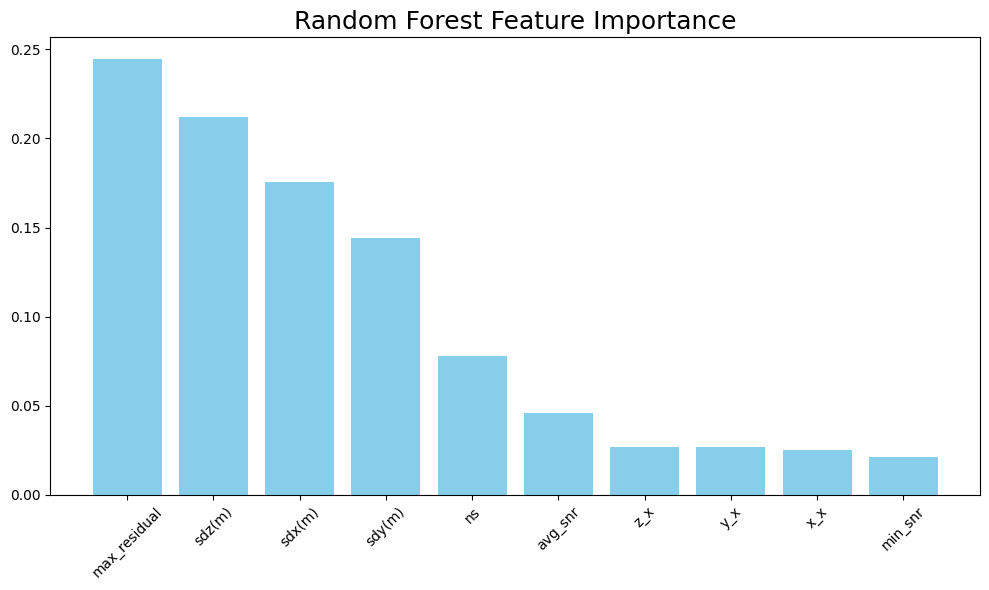


MODEL ACCURACY IMPROVEMENT ANALYSIS
Mean 3D Error (Original): 12.9096 m
Mean 3D Error (Corrected): 2.9997 m

Improvement: 9.9100 m (76.76%)


'\njoblib.dump(best_models, \'best_gnss_model.joblib\')\njoblib.dump(x_scaler, \'x_scaler.joblib\')\njoblib.dump(y_scaler, \'y_scaler.joblib\')\njoblib.dump(feature_cols, \'feature_cols.joblib\')\nprint("\n✓ Best model, scaler, and feature list saved successfully!")\nprint("\n✓ Analysis complete!")'

In [44]:
    # 2) train simple Neural Network (BatchNorm + Dropout)
    # Think of it like asking multiple experts for their opinion and averaging their answers.
best_models, x_scaler, y_scaler, X_test, y_pred = train_ensemble_and_evaluate(unified_df, feature_cols)
test_df = unified_df.loc[X_test.index]

calculate_accuracy_improvement(test_df, y_pred, (spp_x, spp_y, spp_z))
"""
    joblib.dump(best_models, 'best_gnss_model.joblib')
    joblib.dump(x_scaler, 'x_scaler.joblib')
    joblib.dump(y_scaler, 'y_scaler.joblib')
    joblib.dump(feature_cols, 'feature_cols.joblib')
    print("\n✓ Best model, scaler, and feature list saved successfully!")
    print("\n✓ Analysis complete!")"""

above is the data with iono correction